In [1]:
# --- Pakete ---
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
# Für Reproduzierbarkeit – ihr dürft den Seed gern ändern
# np.random.seed(42)

In [3]:
# Kleines Hilfs-Utility für saubere Plots
def finalize_plot(title=None, xlabel=None, ylabel=None):
    if title: plt.title(title)
    if xlabel: plt.xlabel(xlabel)
    if ylabel: plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.show()

## 1) Bernoulli($p$)

Ein einzelner Versuch mit Ergebnis 1 (Erfolg) mit Wahrscheinlichkeit $p$ und 0 (Misserfolg) mit $1-p$.  
**Theorie:** $\mathbb{E}[X]=p$, $\mathrm{Var}(X)=p(1-p)$.

,Bernoulli
0,0
1,1
2,0
3,0
4,0
5,1
6,1
7,0
8,0
9,0


Empirisch: Mittelwert=0.3000, Varianz=0.2100
Theoretisch: Mittelwert=0.3000, Varianz=0.2100


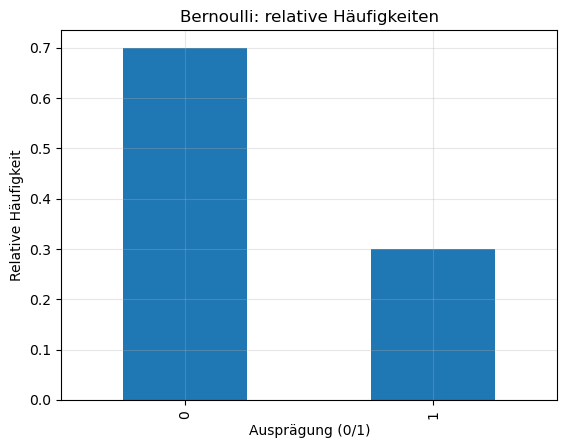

In [4]:
# --- Parameter (ändern!) ---
p = 0.3
n = 10

# --- Simulation ---
x = (np.random.rand(n) < p).astype(int)
df = pd.DataFrame({"Bernoulli": x})
display(df.head(n))

# --- Kennwerte ---
sample_mean = df["Bernoulli"].mean()
sample_var  = df["Bernoulli"].var(ddof=0)

print(f"Empirisch: Mittelwert={sample_mean:.4f}, Varianz={sample_var:.4f}")
print(f"Theoretisch: Mittelwert={p:.4f}, Varianz={p*(1-p):.4f}")

# --- Plot ---
df["Bernoulli"].value_counts(normalize=True).sort_index().plot(kind="bar")
finalize_plot(title="Bernoulli: relative Häufigkeiten", xlabel="Ausprägung (0/1)", ylabel="Relative Häufigkeit")


Bernoulli(p=0.3) mit n=1000 Versuchen
  Empirisch:   Mittelwert=0.3060, Varianz=0.2124
  Theoretisch: Mittelwert=0.3000, Varianz=0.2100


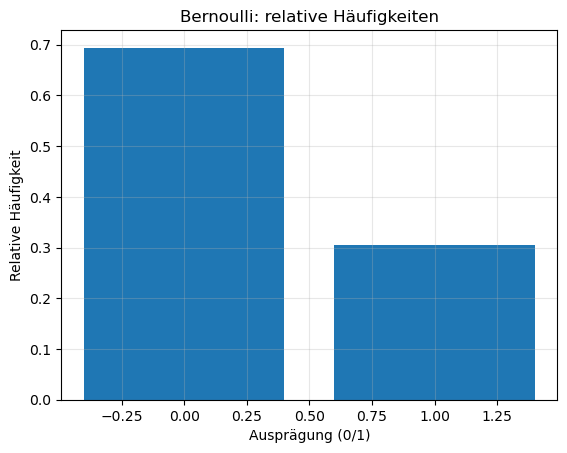

In [5]:
# --- Parameter (ändern!) ---
p = 0.3          # Erfolgswahrscheinlichkeit
n = 1000         # Anzahl unabhängiger Versuche

# --- Simulation ---
x = (np.random.rand(n) < p).astype(int)  # 0/1
sample_mean = x.mean()
sample_var  = x.var(ddof=0)

# --- Vergleich Empirie vs Theorie ---
theo_mean = p
theo_var  = p*(1-p)

print(f"Bernoulli(p={p}) mit n={n} Versuchen")
print(f"  Empirisch:   Mittelwert={sample_mean:.4f}, Varianz={sample_var:.4f}")
print(f"  Theoretisch: Mittelwert={theo_mean:.4f}, Varianz={theo_var:.4f}")

# --- Visualisierung: relative Häufigkeiten von 0 und 1 ---
vals, counts = np.unique(x, return_counts=True)
rel = counts / n
plt.bar(vals, rel)
finalize_plot(title="Bernoulli: relative Häufigkeiten", xlabel="Ausprägung (0/1)", ylabel="Relative Häufigkeit")

**Aufgaben (Bernoulli):**
1. Variiert $p$ (z. B. 0.1, 0.5, 0.9) und beobachtet Mittelwert/Varianz.
2. Erhöht $n$ systematisch. Wie stabilisiert sich der Mittelwert?
3. Zeichnet den **laufenden Mittelwert** (Running Mean) und beschreibt, was ihr seht.


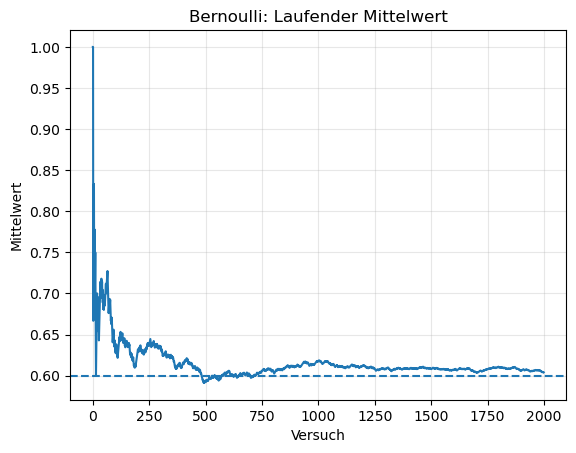

In [6]:
# OPTIONAL: Laufender Mittelwert (Law of Large Numbers)
p = 0.6
n = 2000
x = (np.random.rand(n) < p).astype(int)
running_mean = np.cumsum(x) / (np.arange(n) + 1)

plt.plot(running_mean)
plt.axhline(p, linestyle="--")
finalize_plot(title="Bernoulli: Laufender Mittelwert", xlabel="Versuch", ylabel="Mittelwert")


## 2) Binomial($n, p$)

Zählt die **Anzahl Erfolge** in $n$ unabhängigen Bernoulli($p$)-Versuchen.  
**Theorie:** $\mathbb{E}[X]=np$, $\mathrm{Var}(X)=np(1-p)$.


,Binomial
0,3
1,7
2,2
3,4
4,4


Empirisch: Mittelwert=4.0400, Varianz=2.9984
Theoretisch: Mittelwert=4.0000, Varianz=2.4000


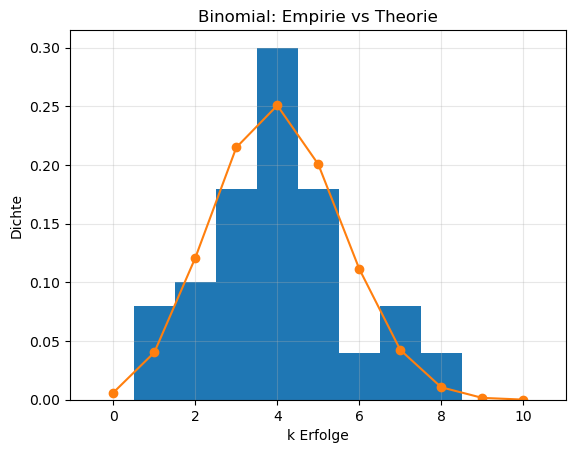

In [7]:
n_trials = 10
p = 0.4
m = 50

samples = np.random.binomial(n_trials, p, size=m)
df = pd.DataFrame({"Binomial": samples})
display(df.head())

print(f"Empirisch: Mittelwert={df['Binomial'].mean():.4f}, Varianz={df['Binomial'].var(ddof=0):.4f}")
print(f"Theoretisch: Mittelwert={n_trials*p:.4f}, Varianz={n_trials*p*(1-p):.4f}")

k_vals = np.arange(0, n_trials+1)
pmf = np.array([math.comb(n_trials, k)*(p**k)*((1-p)**(n_trials-k)) for k in k_vals])

df["Binomial"].plot.hist(bins=np.arange(-0.5, n_trials+1.5, 1), density=True)
plt.plot(k_vals, pmf, marker="o")
finalize_plot(title="Binomial: Empirie vs Theorie", xlabel="k Erfolge", ylabel="Dichte")



Binomial(n=10, p=0.4), m=5000 Experimente
  Empirisch:   Mittelwert=4.0012, Varianz=2.3960
  Theoretisch: Mittelwert=4.0000, Varianz=2.4000


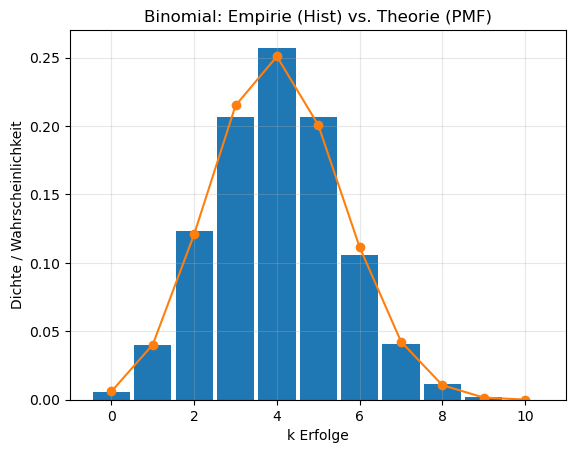

In [8]:
# --- Parameter (ändern!) ---
n_trials = 10     # pro Experiment
p = 0.4
m = 5000          # Anzahl Experimente (Wiederholungen)

# --- Simulation ---
# Variante A: direkte Simulation mit numpy.random.binomial
samples = np.random.binomial(n_trials, p, size=m)

# --- Kennwerte ---
sample_mean = samples.mean()
sample_var  = samples.var(ddof=0)

theo_mean = n_trials * p
theo_var  = n_trials * p * (1 - p)

print(f"Binomial(n={n_trials}, p={p}), m={m} Experimente")
print(f"  Empirisch:   Mittelwert={sample_mean:.4f}, Varianz={sample_var:.4f}")
print(f"  Theoretisch: Mittelwert={theo_mean:.4f}, Varianz={theo_var:.4f}")

# --- Histogramm + theoretische PMF ---
k_vals = np.arange(0, n_trials+1)
def comb(n,k):
    return math.comb(n,k)

pmf = np.array([comb(n_trials, k) * (p**k) * ((1-p)**(n_trials-k)) for k in k_vals])

plt.hist(samples, bins=np.arange(-0.5, n_trials+1.5, 1), density=True, rwidth=0.9)
plt.plot(k_vals, pmf, marker="o")
finalize_plot(title="Binomial: Empirie (Hist) vs. Theorie (PMF)", xlabel="k Erfolge", ylabel="Dichte / Wahrscheinlichkeit")


**Aufgaben (Binomial):**
1. Erhöht $n$ (z. B. 10 → 50 → 200) bei konstantem $p$ und beschreibt die Form der Verteilung.
2. Nutzt $p=0.5$ vs. stark asymmetrische $p$ (z. B. 0.1, 0.9). Wie ändert sich die Form?
3. Vergleicht die Binomialverteilung für große $n$ mit einer **Normalapproximation**.


,Binomial
0,20
1,24
2,21
3,24
4,29


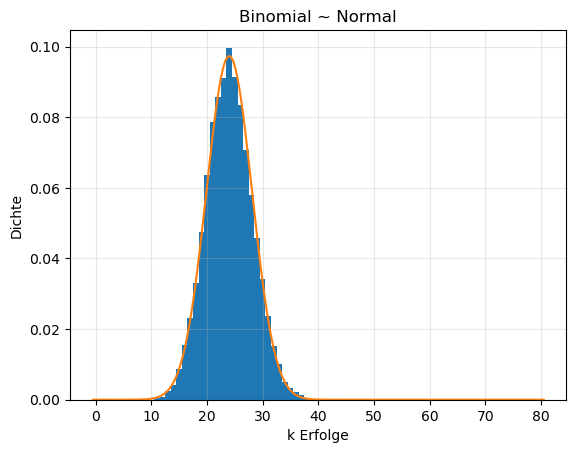

In [9]:
n_trials = 80
p = 0.3
m = 20000
samples = np.random.binomial(n_trials, p, size=m)
df = pd.DataFrame({"Binomial": samples})
display(df.head())

mu = n_trials*p
sigma = math.sqrt(n_trials*p*(1-p))

df["Binomial"].plot.hist(bins=np.arange(-0.5, n_trials+1.5, 1), density=True)
xs = np.linspace(-0.5, n_trials+0.5, 500)
pdf = (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*((xs-mu)/sigma)**2)
plt.plot(xs, pdf)
finalize_plot(title="Binomial ~ Normal", xlabel="k Erfolge", ylabel="Dichte")

## 3) Poisson($\lambda$)

Modelliert **Anzahlen seltener Ereignisse** pro Zeit-/Raumintervall.  
**Theorie:** $\mathbb{E}[X]=\lambda$, $\mathrm{Var}(X)=\lambda$.  
Hinweis: Für große $n$ und kleine $p$ mit $np=\lambda$ ist Binomial $\approx$ Poisson.


,Poisson
0,7
1,3
2,3
3,2
4,1


Empirisch: Mittelwert=3.7250, Varianz=2.7244
Theoretisch: Mittelwert=3.5000, Varianz=3.5000


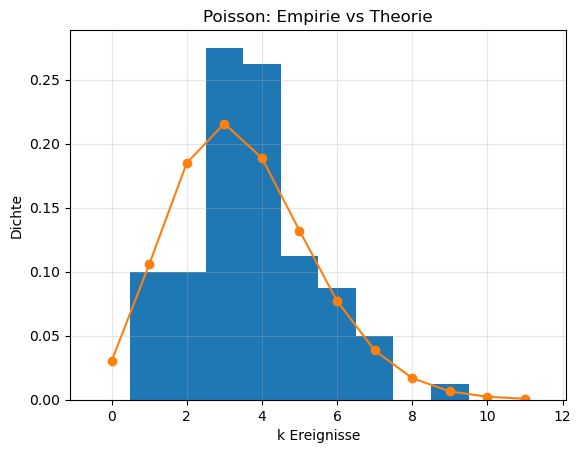

In [10]:
lam = 3.5
m = 80

samples = np.random.poisson(lam=lam, size=m)
df = pd.DataFrame({"Poisson": samples})
display(df.head())

print(f"Empirisch: Mittelwert={df['Poisson'].mean():.4f}, Varianz={df['Poisson'].var(ddof=0):.4f}")
print(f"Theoretisch: Mittelwert={lam:.4f}, Varianz={lam:.4f}")

k_max = int(np.percentile(samples, 99.5)) + 3
k_vals = np.arange(0, k_max+1)
pmf = np.exp(-lam)*(lam**k_vals)/np.array([math.factorial(k) for k in k_vals])

df["Poisson"].plot.hist(bins=np.arange(-0.5, k_max+1.5, 1), density=True)
plt.plot(k_vals, pmf, marker="o")
finalize_plot(title="Poisson: Empirie vs Theorie", xlabel="k Ereignisse", ylabel="Dichte")


Poisson(lam=3.5), m=8000
  Empirisch:   Mittelwert=3.4722, Varianz=3.5122
  Theoretisch: Mittelwert=3.5000, Varianz=3.5000


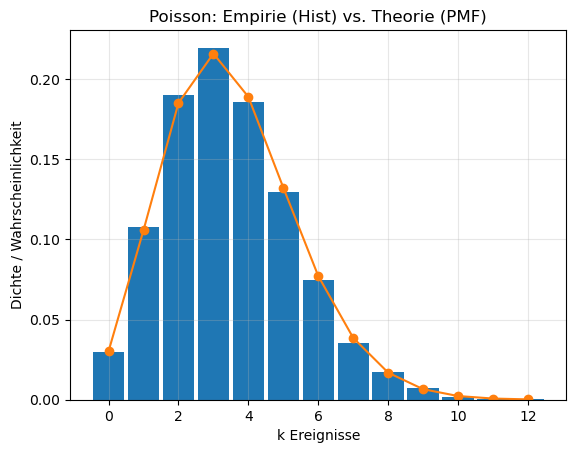

In [11]:
# --- Parameter (ändern!) ---
lam = 3.5     # Erwartungswert / Rate
m = 8000      # Anzahl Experimente

samples = np.random.poisson(lam=lam, size=m)

sample_mean = samples.mean()
sample_var  = samples.var(ddof=0)

print(f"Poisson(lam={lam}), m={m}")
print(f"  Empirisch:   Mittelwert={sample_mean:.4f}, Varianz={sample_var:.4f}")
print(f"  Theoretisch: Mittelwert={lam:.4f}, Varianz={lam:.4f}")

k_max = int(np.percentile(samples, 99.5)) + 3
k_vals = np.arange(0, k_max+1)
pmf = np.exp(-lam) * (lam**k_vals) / np.array([math.factorial(k) for k in k_vals])

plt.hist(samples, bins=np.arange(-0.5, k_max+1.5, 1), density=True, rwidth=0.9)
plt.plot(k_vals, pmf, marker="o")
finalize_plot(title="Poisson: Empirie (Hist) vs. Theorie (PMF)", xlabel="k Ereignisse", ylabel="Dichte / Wahrscheinlichkeit")


**Aufgaben (Poisson):**
1. Variiert $\lambda$ (z. B. 1, 3, 8, 15). Was passiert mit Form und Streuung?
2. Wählt $n$ groß und $p$ klein (mit $np=\lambda$) und vergleicht Binomial mit Poisson (Histogramme übereinanderlegen).
3. Interpretiert $\lambda$ als *Rate* in einem realen Kontext (z. B. Anrufe pro Minute).


,Binomial,Poisson
0,1,3
1,5,2
2,7,2
3,5,2
4,11,2


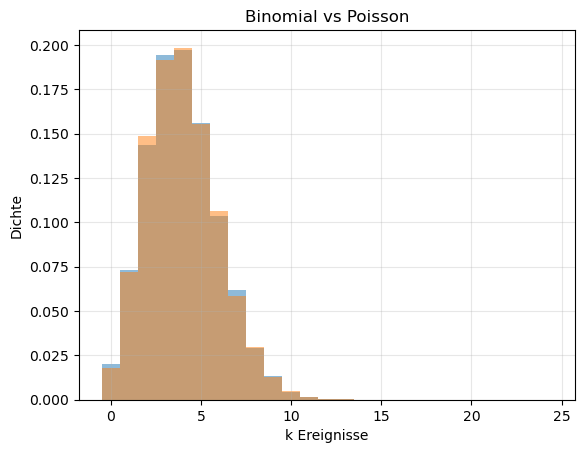

In [12]:
# Binomial → Poisson Vergleich
n_trials = 1000
p = 0.004
lam = n_trials * p
m = 20000

binom_samples = np.random.binomial(n_trials, p, size=m)
pois_samples  = np.random.poisson(lam=lam, size=m)

df = pd.DataFrame({"Binomial": binom_samples, "Poisson": pois_samples})
display(df.head())

plt.hist(df["Binomial"], bins=np.arange(-0.5, int(lam*6)+1.5, 1), density=True, alpha=0.5)
plt.hist(df["Poisson"],  bins=np.arange(-0.5, int(lam*6)+1.5, 1), density=True, alpha=0.5)
finalize_plot(title="Binomial vs Poisson", xlabel="k Ereignisse", ylabel="Dichte")


## 4) Normal($\mu, \sigma$)

Kontinuierliche Verteilung mit Dichte  
$f(x)=\frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right)$.  
**Theorie:** $\mathbb{E}[X]=\mu$, $\mathrm{Var}(X)=\sigma^2$.


,Normal
0,1.220496
1,3.296975
2,2.663207
3,4.496025
4,2.364149


Empirisch: Mittelwert=1.9987, Varianz=2.2904
Theoretisch: Mittelwert=2.0000, Varianz=2.2500


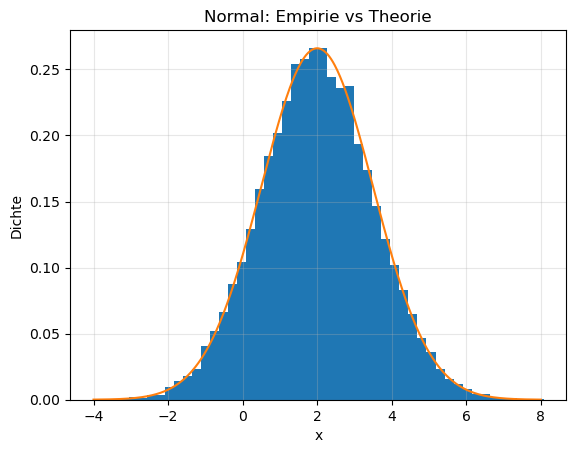

In [13]:
mu = 2.0
sigma = 1.5
m = 20000

samples = np.random.normal(mu, sigma, size=m)
df = pd.DataFrame({"Normal": samples})
display(df.head())

print(f"Empirisch: Mittelwert={df['Normal'].mean():.4f}, Varianz={df['Normal'].var(ddof=0):.4f}")
print(f"Theoretisch: Mittelwert={mu:.4f}, Varianz={sigma**2:.4f}")

df["Normal"].plot.hist(bins=50, density=True)
xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
pdf = (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*((xs-mu)/sigma)**2)
plt.plot(xs, pdf)
finalize_plot(title="Normal: Empirie vs Theorie", xlabel="x", ylabel="Dichte")


Normal(mu=2.0, sigma=1.5), m=20000
  Empirisch:   Mittelwert=1.9836, Varianz=2.2382
  Theoretisch: Mittelwert=2.0000, Varianz=2.2500


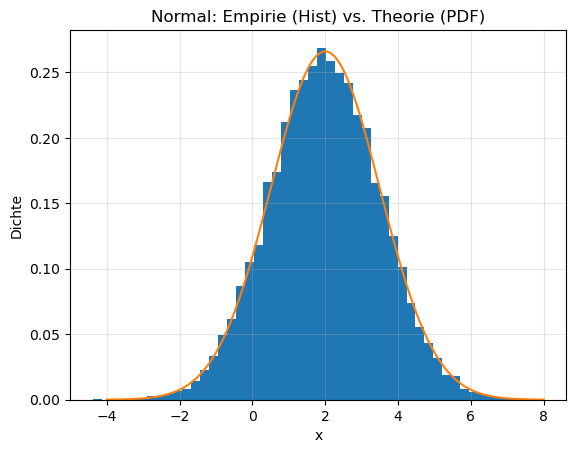

In [14]:
# --- Parameter (ändern!) ---
mu = 2.0
sigma = 1.5
m = 20000

samples = np.random.normal(loc=mu, scale=sigma, size=m)

sample_mean = samples.mean()
sample_var  = samples.var(ddof=0)

print(f"Normal(mu={mu}, sigma={sigma}), m={m}")
print(f"  Empirisch:   Mittelwert={sample_mean:.4f}, Varianz={sample_var:.4f}")
print(f"  Theoretisch: Mittelwert={mu:.4f}, Varianz={sigma**2:.4f}")

plt.hist(samples, bins=50, density=True)

xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs-mu)/sigma)**2)
plt.plot(xs, pdf)
finalize_plot(title="Normal: Empirie (Hist) vs. Theorie (PDF)", xlabel="x", ylabel="Dichte")


**Aufgaben (Normal):**
1. Variiert $\mu$ und $\sigma$. Wie wirkt sich das auf Lage und Breite aus?
2. Simuliert die **Summe vieler unabhängiger** Zufallsvariablen (z. B. Uniform(0,1)) und vergleicht mit Normal (**CLT**).
3. Berechnet empirische Quantile und vergleicht sie mit theoretischen Quantilen.


,Summe,Z-standardisiert
0,4.753601,-1.246399
1,6.554418,0.554418
2,7.474643,1.474643
3,5.425010,-0.574990
4,4.144932,-1.855068


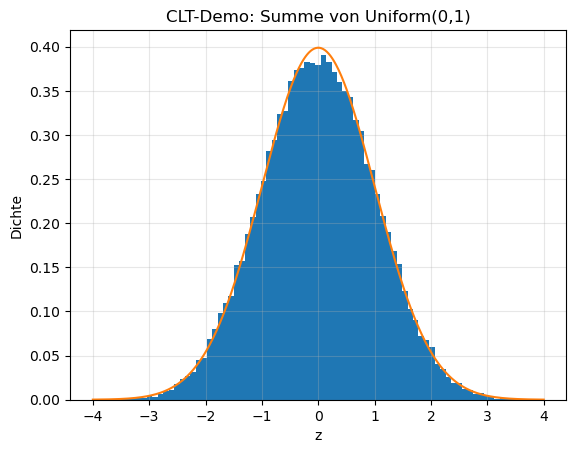

In [15]:
# CLT-Demo
m = 50000
k = 12
sums = np.random.rand(m, k).sum(axis=1)
mu = k/2
sigma = math.sqrt(k/12)
z = (sums - mu)/sigma

df = pd.DataFrame({"Summe": sums, "Z-standardisiert": z})
display(df.head())

df["Z-standardisiert"].plot.hist(bins=80, density=True)
xs = np.linspace(-4, 4, 500)
pdf = (1/np.sqrt(2*np.pi))*np.exp(-0.5*xs**2)
plt.plot(xs, pdf)
finalize_plot(title="CLT-Demo: Summe von Uniform(0,1)", xlabel="z", ylabel="Dichte")
